t+3 
full 
无异常检测  
无滞后特征
无数据增强

In [35]:
import pandas as pd
import os
from sklearn.svm import SVR
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
from features import features
from imblearn.over_sampling import SMOTE
from collections import Counter


path=r"D:\WorkPlace\A_Data\Ca\full"
input_folder = r"D:\WorkPlace\A_Data\input_folder"
# 挑选出3天pam的值

import os
final_file_path = os.path.join(path, "final.csv")
filtered_file_path = os.path.join(path, "final.csv")
output_hysteresis = os.path.join(path, "滞后特征")

# 主循环中传递滞后窗口大小
lag_window = 1  # 可以灵活调整滞后窗口大小
predict_horizon = 3  # 预测几天后的 pam 变化，例如2表示 t+2


In [36]:
features = features  # 假设您有这些特征

input_files = glob(os.path.join(input_folder, "*.csv"))
all_data = []



# 定义滞后特征提取函数
def extract_lagged_features(df, required_columns, lag_window, predict_horizon):
    rows = []
    for i in range(lag_window, len(df)):
        pam_t = df.loc[i, "pam"]
        if i + predict_horizon >= len(df):
            break

        pam_t_future = df.loc[i + predict_horizon, "pam"]

        if pd.isna(pam_t) or pd.isna(pam_t_future):
            continue

        # 提取 t-lag_window 到 t 的特征
        lagged_features = [df.loc[i - j, required_columns] for j in range(lag_window, -1, -1)]
        rolling_window = pd.DataFrame(lagged_features)


        # 构造特征行
        row = (list(rolling_window.values.flatten())
               + [pam_t_future - pam_t])  # 目标值为 t+horizon 的变化
        rows.append(row)
    return rows

# 主循环处理所有输入文件
for file in input_files:
    df = pd.read_csv(file)
    required_columns = [col for col in features if col in df.columns]

    rows = extract_lagged_features(df, required_columns, lag_window, predict_horizon)

    if rows:
        # 构建列名
        columns = (
            [f"{col}_t-{i}" for i in range(lag_window, -1, -1) for col in required_columns]
            + ["target"]
        )

        output_df = pd.DataFrame(rows, columns=columns)
        output_file = os.path.join(output_hysteresis, os.path.basename(file))
        output_df.to_csv(output_file, index=False)
        all_data.append(output_df)

# 3. 合成 Final 文件 ==========

In [37]:
directory_path = output_hysteresis  

final_df = pd.DataFrame()
for file_name in os.listdir(directory_path):
    if file_name.endswith(".csv"):
        file_path = os.path.join(directory_path, file_name)
        df = pd.read_csv(file_path)
        final_df = pd.concat([final_df, df], ignore_index=True)

final_df.to_csv(final_file_path, index=False)


# 5. 数据增强与训练 ==========

In [38]:
data = pd.read_csv(filtered_file_path)
sensor_columns = [col for col in data.columns if col not in ['target']]
data[sensor_columns] = data[sensor_columns].apply(pd.to_numeric, errors='coerce')
data[sensor_columns] = data[sensor_columns].fillna(data[sensor_columns].mean())

# 标准化
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[sensor_columns])
X = pd.DataFrame(scaled_features, columns=sensor_columns)
y = data['target']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_models = [
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )),

    ('svm', SVR(C=1.0, kernel='rbf')),
     ('rf', RandomForestRegressor(n_estimators=200, random_state=42))
]

In [40]:
meta_model = CatBoostRegressor(
    n_estimators=300,
    learning_rate=0.03,
    loss_function='MAE',
    depth=10,
    l2_leaf_reg=3,
    random_state=42
)

model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
)

In [41]:
model.fit(X_train, y_train)

0:	learn: 3.9703006	total: 26.2ms	remaining: 7.83s
1:	learn: 3.9693358	total: 50.6ms	remaining: 7.54s
2:	learn: 3.9685895	total: 73.3ms	remaining: 7.26s
3:	learn: 3.9673626	total: 100ms	remaining: 7.4s
4:	learn: 3.9663001	total: 123ms	remaining: 7.29s
5:	learn: 3.9647463	total: 149ms	remaining: 7.32s
6:	learn: 3.9640279	total: 173ms	remaining: 7.26s
7:	learn: 3.9631523	total: 198ms	remaining: 7.22s
8:	learn: 3.9625322	total: 224ms	remaining: 7.24s
9:	learn: 3.9614200	total: 250ms	remaining: 7.24s
10:	learn: 3.9606414	total: 274ms	remaining: 7.19s
11:	learn: 3.9590743	total: 301ms	remaining: 7.22s
12:	learn: 3.9583971	total: 327ms	remaining: 7.22s
13:	learn: 3.9575093	total: 351ms	remaining: 7.17s
14:	learn: 3.9564328	total: 377ms	remaining: 7.16s
15:	learn: 3.9551165	total: 400ms	remaining: 7.11s
16:	learn: 3.9546652	total: 425ms	remaining: 7.07s
17:	learn: 3.9530264	total: 451ms	remaining: 7.07s
18:	learn: 3.9521492	total: 475ms	remaining: 7.02s
19:	learn: 3.9515098	total: 501ms	remai

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_ra...
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('svm', SVR()),
                              ('rf',
                               RandomForestRegressor(n_estimators=200,
                                                     random_state=42))],
                  final_estimator=<catboost.core.CatBoostRegressor object at 0x00000232285DC910>)

# 6. 评估与可视化 ==========


In [42]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\n测试集上的均方误差（MSE）：{mse}")

# 极端值样本评估
threshold = 2.0
errors = np.abs(y_pred - y_test)
correct_predictions = errors <= threshold

extreme_samples = (np.abs(y_test) > 10)
extreme_mse = mean_squared_error(y_test[extreme_samples], y_pred[extreme_samples])

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")
print(f"极端值样本的MSE：{extreme_mse}")



测试集上的均方误差（MSE）：31.222386686598828

误差在 2.0 范围内的准确率：34.43%
极端值样本的MSE：151.21891516704568


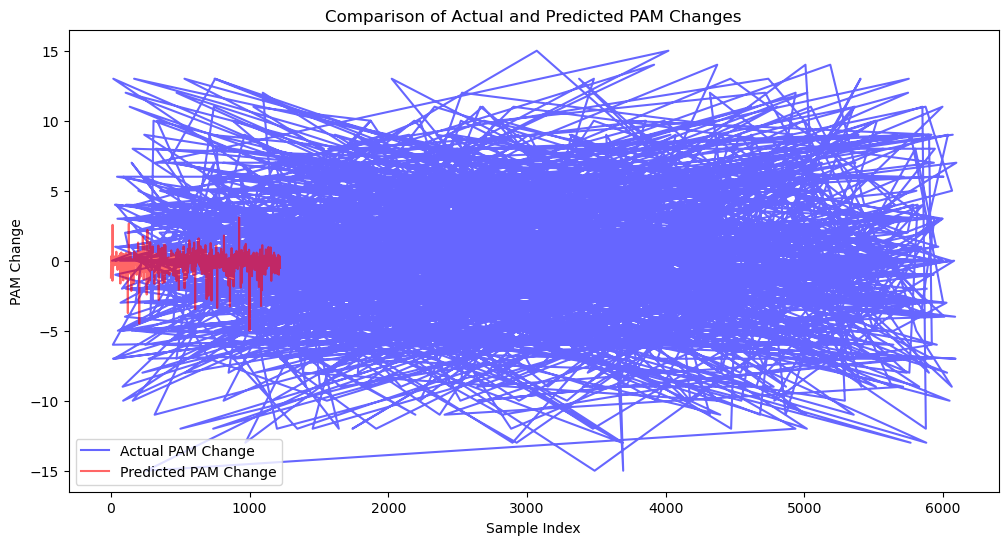

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual PAM Change", color="blue", alpha=0.6)
plt.plot(y_pred, label="Predicted PAM Change", color="red", alpha=0.6)
plt.legend()
plt.title("Comparison of Actual and Predicted PAM Changes")
plt.xlabel("Sample Index")
plt.ylabel("PAM Change")
plt.show()
